In [3]:
import pandas as pd
import numpy as np
import pickle
import re
import time
import os
from math import log2
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm
import nltk

RAW_DIR = "../data/raw"
PREPROCESSED_DIR = "../data/processed"
MODELS = "../models"
for d in [RAW_DIR, MODELS,PREPROCESSED_DIR]:
    os.makedirs(d, exist_ok=True)

# Khai bao duong dan file
CORPUS_PATH = f"{RAW_DIR}/corpus.parquet"
QUERIES_PATH = f"{RAW_DIR}/queries.parquet"
QRELS_PATH = f"{RAW_DIR}/qrels.parquet"

In [4]:
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


DICT_DIR = "../data/dicts"

# Đọc dữ liệu
df = pd.read_parquet(f'{PREPROCESSED_DIR}/data_tv1.parquet')
df = df.dropna(subset=['text_tfidf']).reset_index(drop=True)

qrels_dict   = pickle.load(open(f'{DICT_DIR}/qrels_dict.pkl',   'rb'))
queries_dict = pickle.load(open(f'{DICT_DIR}/queries_dict.pkl', 'rb'))

id_to_idx = pd.Series(df.index, index=df['id'].astype(str))

print(f"Corpus:  {len(df):,} papers")
print(f"Queries: {len(queries_dict):,}")
print(f"Qrels:   {len(qrels_dict):,} queries có ground truth")
print(df[['id','title','text_tfidf']].head(3))

Corpus:  25,657 papers
Queries: 1,000
Qrels:   1,000 queries có ground truth
                                         id  \
0  632589828c8b9fca2c3a59e97451fde8fa7d188d   
1  86e87db2dab958f1bd5877dc7d5b8105d6e31e46   
2  2a047d8c4c2a4825e0f0305294e7da14f8de6fd3   

                                               title  \
0  A hybrid of genetic algorithm and particle swa...   
1  A Hybrid EP and SQP for Dynamic Economic Dispa...   
2  Genetic Fuzzy Systems - Evolutionary Tuning an...   

                                          text_tfidf  
0  hybrid genet algorithm particl swarm optim rec...  
1  hybrid sqp dynam econom dispatch nonsmooth fue...  
2  genet fuzzi system evolutionari tune learn fuz...  


In [5]:
STOP = set(stopwords.words('english'))
PS   = PorterStemmer()

# Compile Regex 1 lần duy nhất để tiết kiệm CPU
PATTERN_NON_ALPHA = re.compile(r'[^a-z\s]')
CUSTOM_STOP_STEMMED = {
    'paper','propos','method','approach','result',
    'show','base','also','howev','therefor','thu',
    'furthermor','present','work','studi',
    'experiment','evalu',
    'use', 'new', 'high' # <-- Đã thêm theo nhận xét
}

def preprocess_query_fast(query: str) -> str:
    query = str(query).lower()
    query = PATTERN_NON_ALPHA.sub(' ', query)
    tokens = [t for t in query.split() if t not in STOP and len(t) > 2]
    stemmed = [PS.stem(t) for t in tokens]
    return ' '.join([t for t in stemmed if t not in CUSTOM_STOP_STEMMED])

class TV1SearchSystem:
    def __init__(self, df, vectorizer=None, tfidf_matrix=None):
        self.df = df
        self.doc_ids = df['id'].astype(str).tolist()
        
        # 1. Khởi tạo TF-IDF nếu chưa truyền vào
        if vectorizer is None or tfidf_matrix is None:
            print("Đang build TF-IDF Matrix...")
            self.vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2, max_df=0.85, sublinear_tf=True)
            self.tfidf_matrix = self.vectorizer.fit_transform(self.df['text_tfidf'])
        else:
            self.vectorizer = vectorizer
            self.tfidf_matrix = tfidf_matrix
            
        # 2. Xây dựng Inverted Index cho Boolean Search
        print("Build Inverted Index cho Boolean")
        self.inverted_index = {}
        for idx, text in enumerate(self.df['text_tfidf']):
            if pd.isna(text): continue
            for word in set(text.split()):
                if word not in self.inverted_index:
                    self.inverted_index[word] = set()
                self.inverted_index[word].add(idx)
        print("Hoàn tất khởi tạo Search Engine!")

    def search_tfidf(self, query: str, top_k: int = 10) -> pd.DataFrame:
        q_proc = preprocess_query_fast(query)
        if not q_proc: return pd.DataFrame()
        
        q_vec = self.vectorizer.transform([q_proc])
        scores = cosine_similarity(q_vec, self.tfidf_matrix).flatten()
        
        nonzero_idx = scores.nonzero()[0]
        if len(nonzero_idx) == 0: return pd.DataFrame()
        
        best_idx = nonzero_idx[scores[nonzero_idx].argsort()[::-1][:top_k]]
        res = self.df.iloc[best_idx][['id', 'title', 'abstract']].copy()
        res['score'] = scores[best_idx].round(4)
        res['method'] = 'TF-IDF'
        return res.reset_index(drop=True)

    def search_boolean(self, query: str, mode: str = 'AND', top_k: int = 10) -> pd.DataFrame:
        tokens = preprocess_query_fast(query).split()
        token_sets = df['text_tfidf'].fillna('').str.split().apply(set)
        if not tokens: return pd.DataFrame()

        valid_tokens = [t for t in tokens if t in self.inverted_index]
        if mode == 'AND' and len(valid_tokens) < len(tokens):
            return pd.DataFrame()
        if not valid_tokens:
            return pd.DataFrame()

        # O(1) Search bằng Set Giao/Hợp
        if mode == 'AND':
            match_indices = set.intersection(*[self.inverted_index[t] for t in valid_tokens])
        else: # OR
            match_indices = set.union(*[self.inverted_index[t] for t in valid_tokens])

        if not match_indices: return pd.DataFrame()

        match_indices = list(match_indices)
        res = self.df.iloc[match_indices][['id', 'title', 'abstract']].copy()
        
        if mode == 'AND':
            res['match_score'] = len(tokens)
        else:
            res['match_score'] = res.index.map(lambda idx: sum(1 for t in valid_tokens if idx in self.inverted_index[t]))
        
        res = res.sort_values('match_score', ascending=False).head(top_k)
        res['method'] = f'Boolean-{mode}'
        return res.reset_index(drop=True)

# Tạo Search Engine
search_engine = TV1SearchSystem(df)

Đang build TF-IDF Matrix...
Build Inverted Index cho Boolean
Hoàn tất khởi tạo Search Engine!


In [6]:
def print_results(res: pd.DataFrame, top: int = 5):
    if res is None or res.empty:
        print("  [Không tìm thấy kết quả phù hợp]")
        return
        
    # Xác định cột điểm số dựa vào mô hình (Cosine score hoặc Boolean match_score)
    score_col = 'score' if 'score' in res.columns else 'match_score'
    
    for _, row in res.head(top).iterrows():
        # Định dạng title ngắn gọn tránh tràn dòng
        title = str(row['title']).replace('\n', ' ')
        print(f"  [{row[score_col]:.4f}] {title[:65]}...")

# Danh sách các câu truy vấn mẫu của SCIDOCS
TEST_QUERIES = [
    "citation recommendation scientific papers",
    "information retrieval neural network",
    "graph based document ranking",
    "biomedical text classification",
    "knowledge graph embedding",
]

# Chạy test qua từng câu truy vấn
for q in TEST_QUERIES:
    print(f"  Query: \"{q}\"")

    print(f"\n  TF-IDF")
    # Gọi hàm search từ object search_engine
    print_results(search_engine.search_tfidf(q, top_k=5))

    print(f"\n  Boolean AND")
    # Gọi hàm search từ object search_engine
    print_results(search_engine.search_boolean(q, mode='AND', top_k=5))
    
    print(f"\n  Boolean OR")
    # Gọi hàm search từ object search_engine
    print_results(search_engine.search_boolean(q, mode='OR', top_k=5))
    
    print(f"\n  Boolean NOT")
    # Gọi hàm search từ object search_engine
    print_results(search_engine.search_boolean(q, mode='NOT', top_k=5))

  Query: "citation recommendation scientific papers"

  TF-IDF
  [0.4641] RefSeer: A citation recommendation system...
  [0.3682] Scientific Paper Summarization Using Citation Summary Networks...
  [0.3615] Recommending citations with translation model...
  [0.3500] Worthiness of Sentences in Scientific Reports...
  [0.3477] Digital Libraries and Autonomous Citation Indexing...

  Boolean AND
  [3.0000] Health-related quality of life in breast cancer patients: A bibli...
  [3.0000] Adverse Effects Associated with Protein Intake above the Recommen...
  [3.0000] Worthiness of Sentences in Scientific Reports...

  Boolean OR
  [3.0000] Worthiness of Sentences in Scientific Reports...
  [3.0000] Adverse Effects Associated with Protein Intake above the Recommen...
  [3.0000] Health-related quality of life in breast cancer patients: A bibli...
  [2.0000] Co-word analysis and thematic landscapes in Spanish information s...
  [2.0000] Autonomous Underwater Vehicles : Trends and Transformations

In [7]:
def precision_at_k(retrieved, relevant, k):
    hits = sum(1 for doc_id in retrieved[:k] if str(doc_id) in relevant and relevant[str(doc_id)] > 0)
    return hits / k

def recall_at_k(retrieved, relevant, k):
    total = sum(1 for v in relevant.values() if v > 0)
    if total == 0: return 0.0
    hits = sum(1 for doc_id in retrieved[:k] if str(doc_id) in relevant and relevant[str(doc_id)] > 0)
    return hits / total

def ndcg_at_k(retrieved, relevant, k):
    def dcg(ranked):
        return sum(relevant.get(str(doc_id), 0) / log2(rank + 2) for rank, doc_id in enumerate(ranked[:k]))
    actual = dcg(retrieved)
    ideal  = dcg(sorted(relevant, key=relevant.get, reverse=True))
    return actual / ideal if ideal > 0 else 0.0

def mrr(retrieved, relevant):
    for rank, doc_id in enumerate(retrieved, 1):
        if str(doc_id) in relevant and relevant[str(doc_id)] > 0:
            return 1.0 / rank
    return 0.0

def average_precision(retrieved, relevant):
    hits, ap, total = 0, 0.0, sum(1 for v in relevant.values() if v > 0)
    if total == 0: return 0.0
    for i, doc_id in enumerate(retrieved, 1):
        if str(doc_id) in relevant and relevant[str(doc_id)] > 0:
            hits += 1
            ap   += hits / i
    return ap / total

def evaluate_vectorized(engine, queries, qrels, k_values=[5, 10, 20]):
    """Đánh giá bằng nhân chập Ma trận - Nhanh gấp 10 lần loop cũ"""
    t0 = time.time()
    valid_qids = [qid for qid in queries.keys() if qid in qrels and qrels[qid]]
    
    processed_queries = [preprocess_query_fast(queries[qid]) for qid in valid_qids]
    q_matrix = engine.vectorizer.transform(processed_queries)
    sim_matrix = q_matrix.dot(engine.tfidf_matrix.T) # Nhân ma trận
    
    records = []
    max_k = max(k_values) + 5
    
    for i, qid in enumerate(tqdm(valid_qids, desc="Eval TF-IDF (Vectorized)")):
        relevant = qrels[qid]
        scores = sim_matrix[i].toarray().flatten()
        nonzero_idx = scores.nonzero()[0]
        
        if len(nonzero_idx) == 0:
            retrieved_ids = []
        else:
            top_indices = nonzero_idx[scores[nonzero_idx].argsort()[::-1][:max_k]]
            retrieved_ids = [engine.doc_ids[idx] for idx in top_indices]
        
        rr = mrr(retrieved_ids, relevant)
        ap = average_precision(retrieved_ids, relevant)
        
        for k in k_values:
            records.append({
                'query_id': qid, 'method': 'TFIDF', 'k': k,
                'P@K': round(precision_at_k(retrieved_ids, relevant, k), 4),
                'R@K': round(recall_at_k(retrieved_ids, relevant, k), 4),
                'NDCG@K': round(ndcg_at_k(retrieved_ids, relevant, k), 4),
                'MRR': round(rr, 4), 'AP': round(ap, 4),
            })
            
    print(f"  Latency: {(time.time() - t0) * 1000 / len(valid_qids):.1f}ms/query")
    return pd.DataFrame(records)

def evaluate_random(qrels, doc_ids, k_values=[5, 10, 20]):
    np.random.seed(42)
    records = []
    valid_qids = [qid for qid in qrels.keys() if qrels[qid]]
    for qid in tqdm(valid_qids, desc="Eval Random"):
        relevant = qrels[qid]
        retrieved = np.random.choice(doc_ids, max(k_values)+5, replace=False).tolist()
        for k in k_values:
            records.append({
                'query_id': qid, 'method': 'RANDOM', 'k': k,
                'P@K': round(precision_at_k(retrieved, relevant, k), 4),
                'R@K': round(recall_at_k(retrieved, relevant, k), 4),
                'NDCG@K': round(ndcg_at_k(retrieved, relevant, k), 4),
                'MRR': 0.0, 'AP': 0.0,
            })
    return pd.DataFrame(records)

In [24]:
import time

df_tfidf = evaluate_vectorized(search_engine, queries_dict, qrels_dict)

summary = df_tfidf.groupby(['method','k'])[['P@K','R@K','NDCG@K']].mean().round(4)

# In bảng chỉ số
print(summary.to_string())

# Tính toán lại MAP (Mean Average Precision)
map_score = df_tfidf[df_tfidf['method'] == 'TFIDF']['AP'].mean()
print("")
print(f"MAP (Mean Average Precision): {map_score:.4f}")
print(f'MRR(Mean Reciprocal Rank): {df_tfidf[df_tfidf["method"] == "TFIDF"]["MRR"].mean():.4f}')

# 4. Lưu kết quả ra file CSV
output_path = f"{MODELS}/tv1_tfidf_only_eval.csv"
df_tfidf.to_csv(output_path, index=False)

Eval TF-IDF (Vectorized):   0%|          | 0/1000 [00:00<?, ?it/s]

  Latency: 1.6ms/query
              P@K     R@K  NDCG@K
method k                         
TFIDF  5   0.1050  0.1067  0.1174
       10  0.0787  0.1592  0.1462
       20  0.0542  0.2193  0.1719

MAP (Mean Average Precision): 0.0942
MRR(Mean Reciprocal Rank): 0.2558


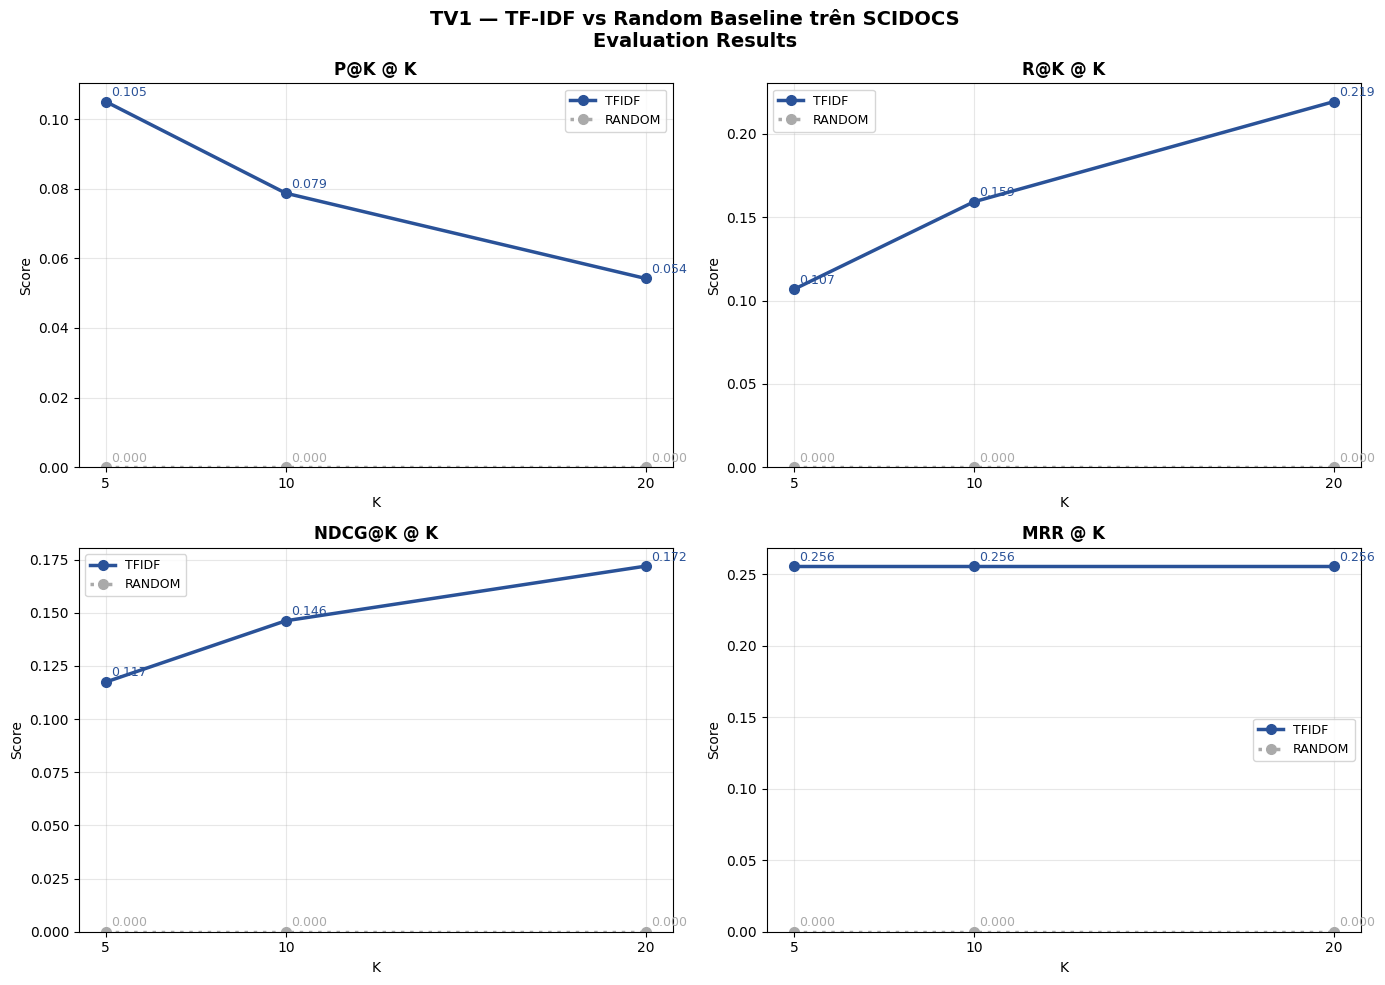

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('TV1 — TF-IDF vs Random Baseline trên SCIDOCS\nEvaluation Results', fontsize=14, fontweight='bold')

COLORS = {'TFIDF':'#2a5298', 'RANDOM':'#aaaaaa'}
LS     = {'TFIDF':'-', 'RANDOM':':'}
k_vals = [5, 10, 20]

for ax, metric in zip(axes.flatten(), ['P@K','R@K','NDCG@K','MRR']):
    for m in ['TFIDF', 'RANDOM']:
        vals = []
        for k in k_vals:
            try:    vals.append(summary.loc[(m,k), metric])
            except: vals.append(0)
            
        ax.plot(k_vals, vals, label=m, color=COLORS.get(m,'gray'),
                linewidth=2.5, marker='o', markersize=7, linestyle=LS.get(m,'-'))
        for k, v in zip(k_vals, vals):
            ax.annotate(f'{v:.3f}', xy=(k,v), xytext=(4,4), textcoords='offset points',
                        fontsize=9, color=COLORS.get(m,'gray'))

    ax.set_title(f'{metric} @ K', fontweight='bold')
    ax.set_xlabel('K'); ax.set_ylabel('Score')
    ax.set_xticks(k_vals); ax.set_ylim(bottom=0)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
import os
import pickle


os.makedirs(MODELS, exist_ok=True)

# 1. Lưu bộ từ điển TF-IDF (Vectorizer)
pickle.dump(search_engine.vectorizer, open(f'{MODELS}/tfidf_vectorizer.pkl', 'wb'))

# 2. Lưu ma trận vector của toàn bộ bài báo (Matrix)
pickle.dump(search_engine.tfidf_matrix, open(f'{MODELS}/tfidf_matrix.pkl', 'wb'))

# 3. Lưu mục lục tìm kiếm Boolean (Inverted Index)
pickle.dump(search_engine.inverted_index, open(f'{MODELS}/inverted_index.pkl', 'wb'))

print(f"Đã lưu model tại thư mục: {MODELS}/")

Đã lưu model tại thư mục: ../models/
